<a href="https://colab.research.google.com/github/RizkyFirdiansyah/PCVK_Ganjil2026/blob/main/Week06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

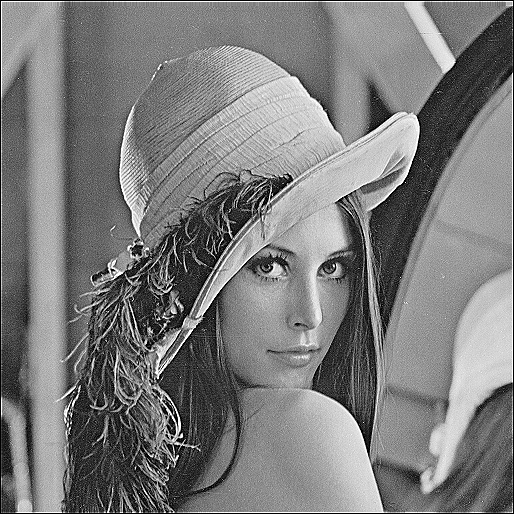

In [ ]:
def convolution2d(image, kernel, stride, padding):
  if padding > 0:
    padded_img = np.pad(image, ((padding, padding), (padding, padding)), 'constant', constant_values=0)
  else:
    padded_img = image

  kernel_height, kernel_width = kernel.shape
  image_height, image_width = padded_img.shape

  output_height = math.floor((image_height - kernel_height) / stride) + 1
  output_width = math.floor((image_width - kernel_width) / stride) + 1

  output = np.zeros((output_height, output_width))

  for y in range(output_height):
    for x in range(output_width):
      sub_matrix = padded_img[y*stride:y*stride+kernel_height, x*stride:x*stride+kernel_width]
      output[y, x] = np.sum(sub_matrix * kernel)

  return np.clip(output, 0, 255).astype(np.uint8)

img = cv.imread('/content/drive/MyDrive/PCVK2026/Lenna.png')
gray_img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
kernel_sharpen = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
sharpened_img = convolution2d(gray_img, kernel_sharpen, 1, 2)
cv2_imshow(sharpened_img)

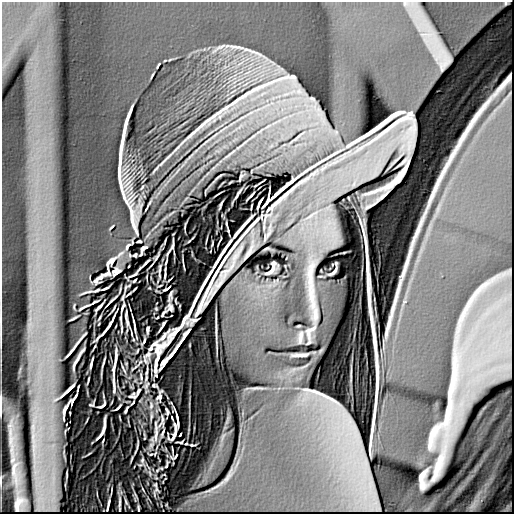

In [ ]:
# Kernel Emboss
kernel_emboss = np.array([[-2, -1, 0], [-1, 1, 1], [0, 1, 2]])
emboss_img = convolution2d(gray_img, kernel_emboss, 1, 2)
cv2_imshow(emboss_img)

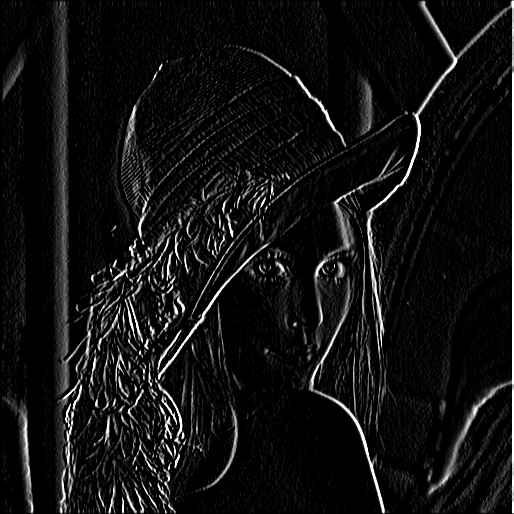

In [ ]:
# Kernel Left Sobel Edge Detection
kernel_lsed = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]])
lsed_img = convolution2d(gray_img, kernel_lsed, 1, 2)
cv2_imshow(lsed_img)

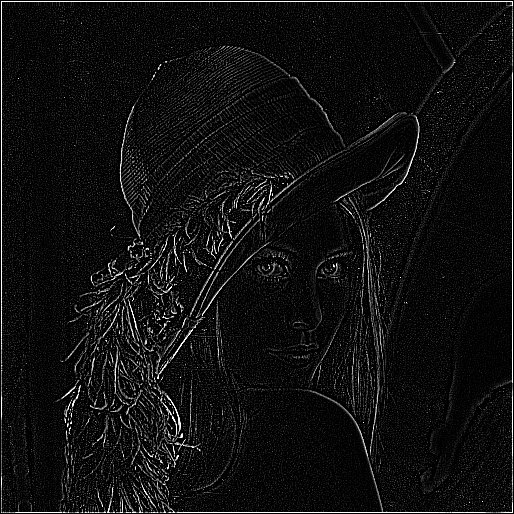

In [ ]:
# Kernel Canny Edge Detection
kernel_ced = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])
ced_img = convolution2d(gray_img, kernel_ced, 1, 2)
cv2_imshow(ced_img)

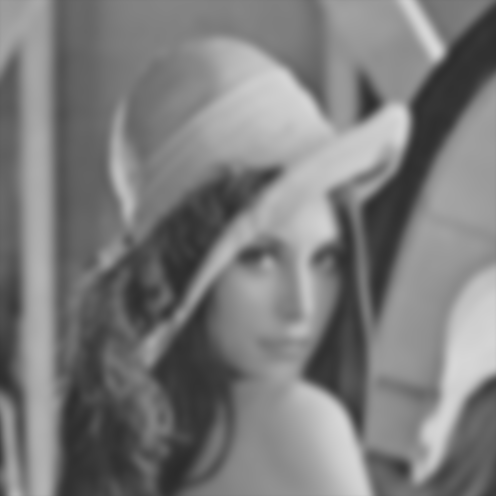

In [ ]:
# Kernel Gaussian Blur (21x21)
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = gaussian_kernel @ gaussian_kernel.transpose()
gauss_img = convolution2d(gray_img, gauss_kernel, 1, 2)
cv2_imshow(gauss_img)

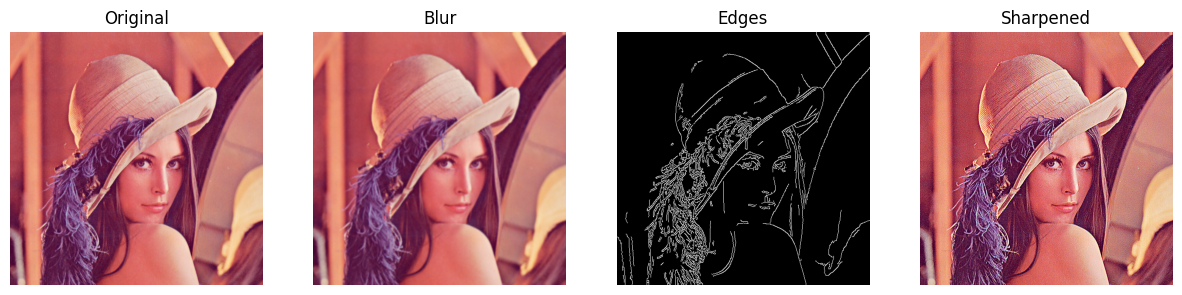

In [ ]:
# Filter menggunakan library filter2d

# Fungsi tampil berdampingan
def  show_side_by_side(images, titles, figsize=(15,5)):
  plt.figure(figsize=figsize)
  for i, (img, title) in enumerate(zip(images, titles)):
    if len(img.shape) == 2:
      plt.subplot(1, len(images), i+1)
      plt.imshow(img, cmap='gray')
    else:
      plt.subplot(1, len(images), i+1)
      plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
  plt.show()

img = cv.imread('/content/drive/MyDrive/PCVK2026/Lenna.png')
gray_img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0], [-1,5,-1], [0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, edges, sharpened], ['Original', 'Blur', 'Edges', 'Sharpened'])

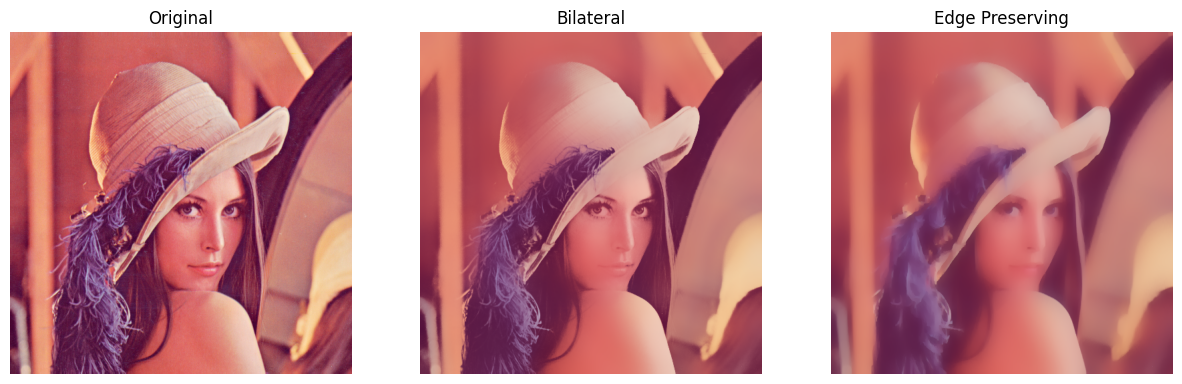

In [21]:
# Filter modern dari OpenCV

# Bilateral filter
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving Filter
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve], ['Original', 'Bilateral', 'Edge Preserving'])